# Part 1: Global sensitivity analysis. A flood case study.

We consider a simplified first model simulating flooding events.
The model has $8$ input random variables, viewed as random variables:

* $X_{1} = Q$, Maximal annual flowrate (m$^3$/s), Gumbel ${\mathcal G}(1013, 558)$ truncated on $[500 , 3000 ]$
* $X_{2}=K_s$, Strickler coefficient, Normal ${\mathcal N}(30, 8^2)$ truncated on $[15 , +\infty [$
* $X_{3} = Z_v$, River downstream level (m), Triangular ${\mathcal T}(49, 51)$ 
* $X_{4} = Z_m$, River upstream level (m), Triangular  ${\mathcal T}(54, 56)$
* $X_{5} = H_d$, Dyke height (m),  Uniform ${\mathcal U}[7, 9]$ 
* $X_{6} = C_b$, Bank level (m), Triangular ${\mathcal T}(55, 56)$
* $X_{7} = L$, River stretch (m), Triangular ${\mathcal T}(4990, 5010)$
* $X_{8} = B$, River width (m), Triangular ${\mathcal T}(295, 305)$

We consider two variables of interest. First, the maximal annual overflow $S$ (in meters), obtained from simplified hydro-dynamical equations of Saint-Venant:
\begin{equation}
S = \left(\frac{Q}{BK_s \sqrt{\frac{Z_m-Z_v}{L} }} \right)^{0.6} + Z_v - H_d - C_b \,.
\end{equation}
Secondly, the cost (in million euros) of the damage on the dyke $Y$, depending on $S$, written as:
\begin{equation}
Y = 1_{S>0} +  \left[0.2 + 0.8\left( 1-\exp^{-\frac{1000}{S^4}}\right) \right] 1_{S \leq 0} + \frac{1}{20}\left(H_d 1_{H_d>8} + 8 1_{H_d \leq 8} \right) \,,
\end{equation}
where $1_{A}(x)$ is the indicator function which is equal to 1 for $x \in A$ and 0 otherwise.
The aim is to perform a global sensitivity analysis, for instance, for $Y$. In particular, we would like to detect the non-essential input variables.


### Packages and preparation

In [25]:
# Packages

import numpy as np
import matplotlib.pyplot as plt
# Flood model
import flood

## Model set and preliminary visualization

In [28]:
floodInputNames = ["Q", "Ks", "Zv", "Zm", "Hd", "Cb", "L", "B"]
d = len(floodInputNames) # Dimension
N = 200
X = flood.getSample(N)
Y = flood.model(X)

We plot that output versus the input variables.

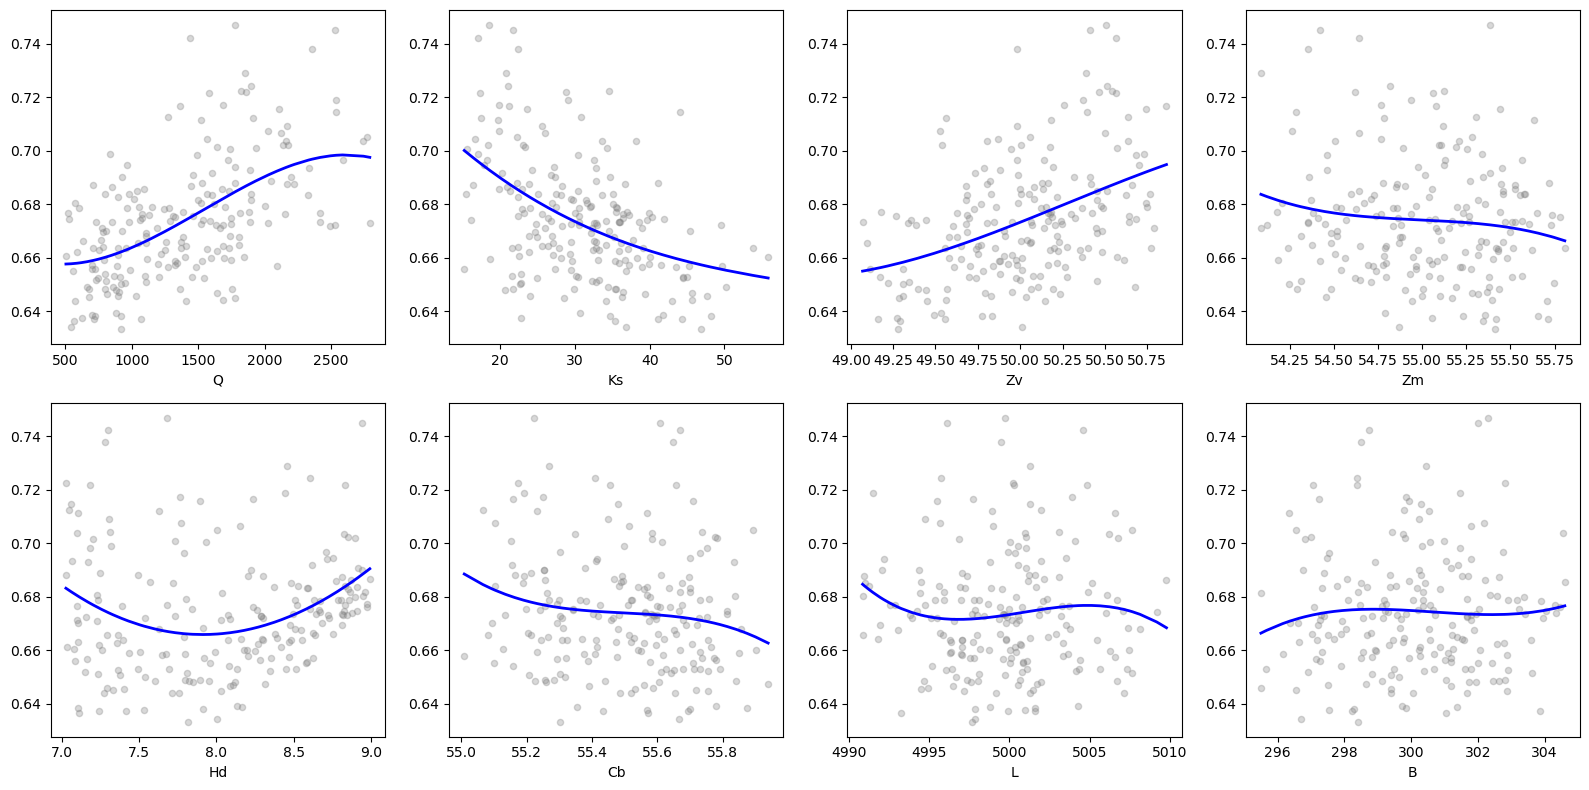

In [31]:
# Main effects

fig, axes = plt.subplots(2, 4, figsize=(16, 8)) #create subfigures. Each "ax" is a subfigure
axes_flat = axes.flatten() #a simple array is used to stock the figures

for i in range(d):
    ax = axes_flat[i]
    ax.scatter(X[:, i], Y, color="grey", s=20, alpha=0.3)
    ax.set_xlabel(floodInputNames[i])
    
    # Sort X for plotting purposes
    idx = np.argsort(X[:, i])
    x_sort = X[idx, i]
    y_sort = Y[idx]
    
    # Fit a polynomial to have an idea of the main effects
    z = np.polyfit(x_sort, y_sort, 3)
    p = np.poly1d(z)
    
    ax.plot(x_sort, p(x_sort), color="blue", linewidth=2)
    
plt.tight_layout()
plt.show()

## Sobol indices estimation

Here we define a function that computes the pick-freeze estimators of the first order Sobol indices $S_i$ for each variable $X_i$. 

Consider two independent $N$ samples $X^1,\dots,X^N$ and ${X^*}^1,\dots,{X^*}^N$ and denote
$$Y^k=f(X^k),\quad Y_{i,k}=f(X_i^k,{X_{-i}^{*^k}})$$
The pick-freeze estimator of each $S_i$ is defined as
$$\widehat{S_i}=\frac{\widehat{\underline{D}_i}}{\hat{D}},$$
where
$$\widehat{\underline{D}}_i = \frac{1}{N} \sum_{k=1}^{N} Y^k Y^{i,k} - \left( \widehat{f}_0 \right)^2, \quad \widehat{f}_0 = \frac{1}{N} \sum_{k=1}^{N} \left[ \frac{Y^k + Y^{i,k}}{2} \right]$$
$$\widehat{D} = \frac{1}{N} \sum_{k=1}^{N} \left[ \frac{(Y^k)^2 + (Y^{i,k})^2}{2} \right] - \left( \widehat{f}_0 \right)^2$$

In [35]:
def sobol_index(model,N):
    X = flood.getSample(N) # First sample
    X_star = flood.getSample(N) # Second sample

    Y = flood.model(X)

    sobol_index = np.zeros(d) # total Sobol indices storage
    
    for i in range(d):
        Xi_star = np.copy(X_star) # We copy the second sample
        Xi_star[:, i] = X[:, i] # Replacing the i-variables of X_star with those of X
        Yi = flood.model(Xi_star)
        
        f0 = (1/N) * np.sum((Y + Yi) / 2) # Compute the empirical mean f0
    
        DI = (1/N) * np.sum(Y * Yi) - (f0**2) # Compute the numerator (empirical covariance) #Maybe just uncomment these two ones
    
        D = (1/N) * np.sum((Y**2 + Yi**2) / 2) - (f0**2) #Compute the nenominator (total variance)
    
        sobol_index[i] = DI/D  #total Index
    
    return sobol_index

<div class="alert alert-block alert-success">
    <b>Task:</b> Inspect the formula and the code. What is the total number of evaluations of the model?
</div>

**R:** $N \times (d+1)$

<div class="alert alert-block alert-success">
    <b>Task:</b> Test the function in the chunk code below. Try it with different sample sizes $N$.
</div>

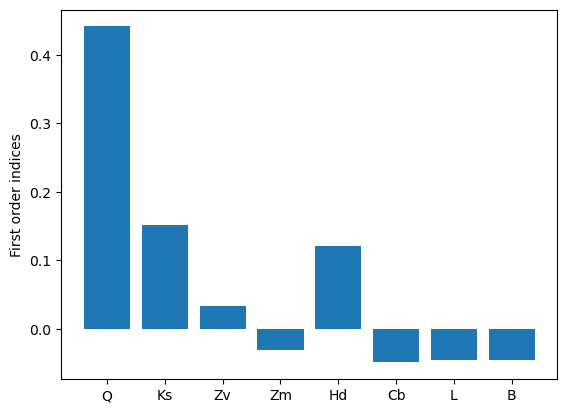

In [48]:
# Test the function

N = 40 # Sample size

plt.bar(range(8),sobol_index(flood.model,N)) # add it
plt.xticks(range(8), floodInputNames)
plt.ylabel("First order indices")
plt.show()

## Convergence study

In order to study the convergence of the estimator properly, we consider different sample sizes $N$ and for each $N$, repeat the numerical experiment multiple times to trace boxplots representing confidence intervals.


In [52]:
nSample = [40,160, 640, 1280,2560] # Sample sizes N
nRep = 30 # For each N in nSample, we repeat the numerical nRep times

Sobol = np.zeros((len(nSample),nRep,8)) # All the indices are stored here

for i, N in enumerate(nSample):
    for k in range(nRep):
        Sobol[i, k, :] = sobol_index(flood.model, N)

### Fancy boxplots

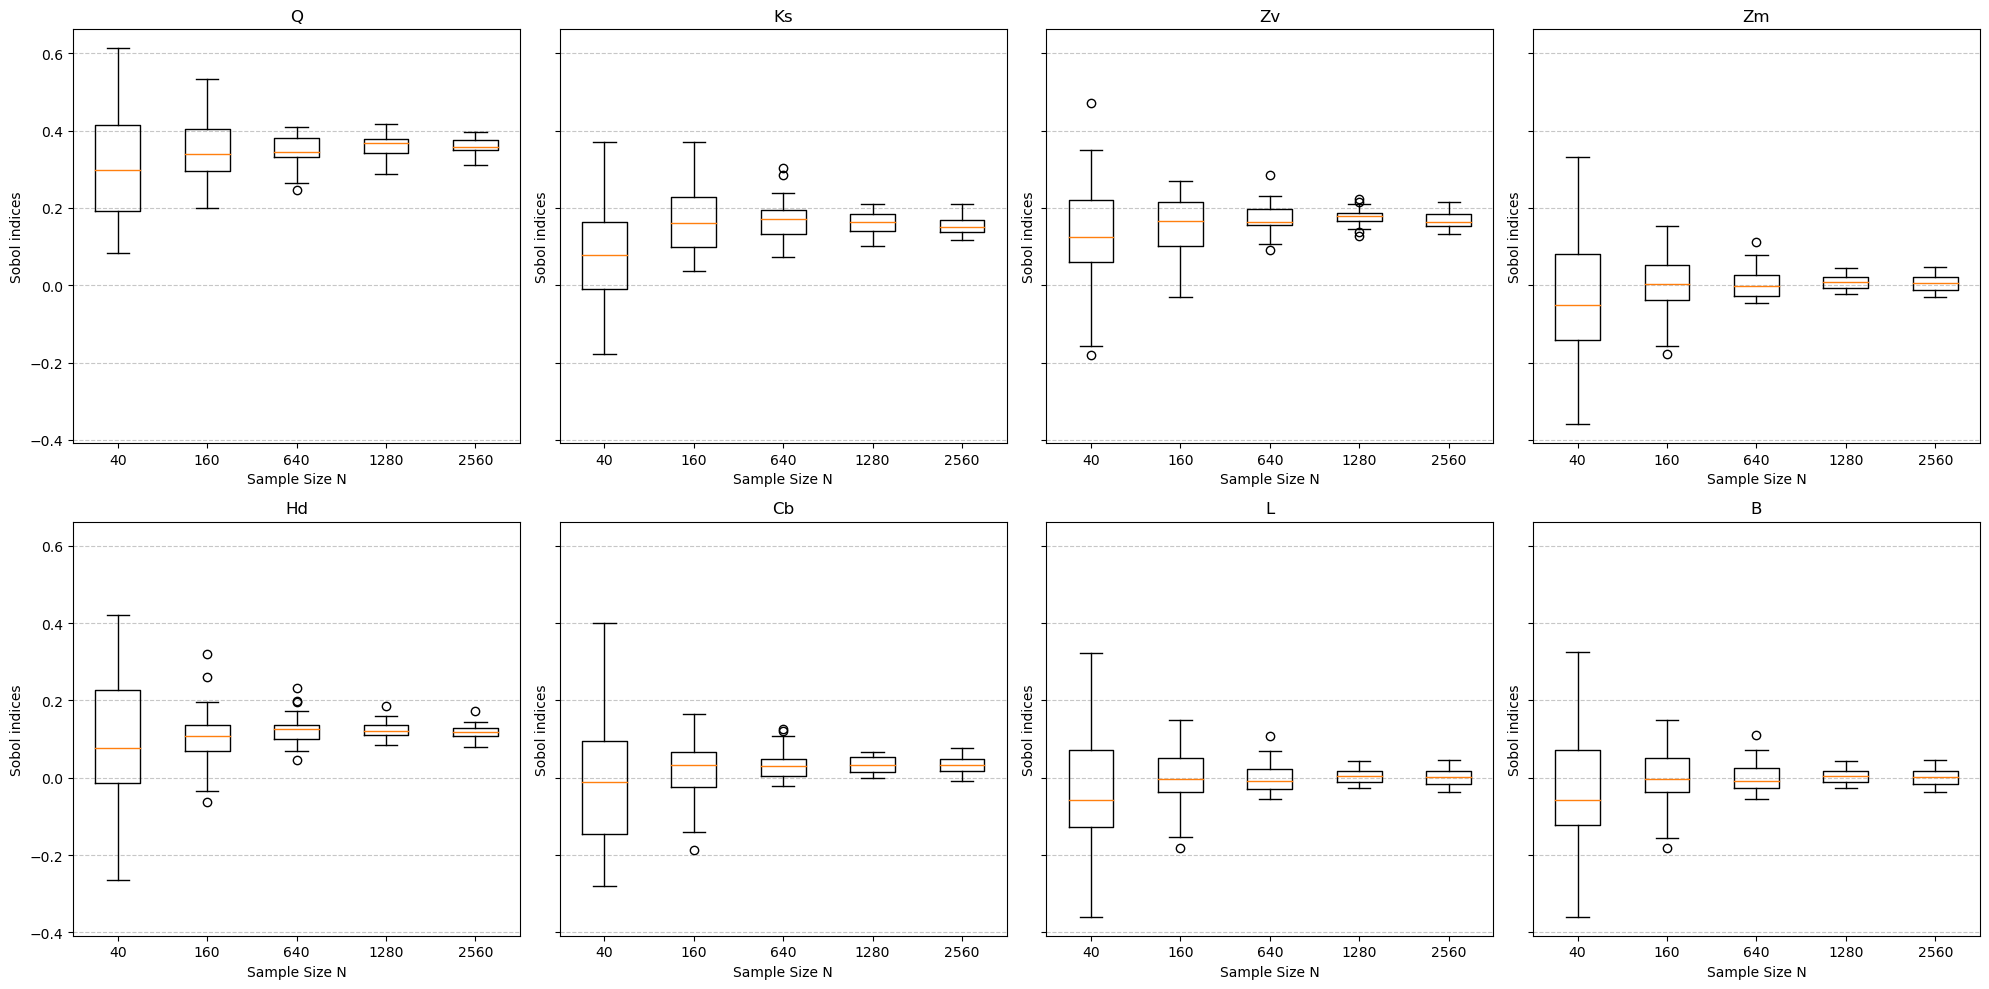

In [59]:
# Use this to visualize the results

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharey=True)
axes = axes.flatten()

for i in range(8):
    plot_data = [Sobol[j, :, i] for j in range(len(nSample))] # A bunch of blocks with values, for each nSample

    ax = axes[i]
    
    ax.boxplot(plot_data, labels=nSample) 
    
    ax.set_title(floodInputNames[i])
    ax.set_xlabel('Sample Size N')
    
    ax.set_ylabel('Sobol indices')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
    <b>Task:</b> Which sample sizes provide good results?
</div>